In [1]:
import sys 
import os

In [2]:
current_dir = os.path.dirname(os.path.abspath('.'))
project_root = os.path.abspath(os.path.join(current_dir, ".."))
sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import yaml
import os
import pickle
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import shap

In [4]:
yaml_path = rf"..\config\config.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

In [5]:
yaml_path = rf"..\config\model.yaml"
with open(yaml_path, "r", encoding="utf-8") as f:
    config_model = yaml.safe_load(f)

# Params

# Read Train / val dataset

In [6]:
pipeline_name="Pipeline3"

In [7]:
X_train = pd.read_parquet(fr'..\data\feature_eng\X_train_feat_eng_{pipeline_name}.parquet')
y_train = pd.read_parquet(fr'..\data\feature_eng\y_train_feat_eng_{pipeline_name}.parquet')  

X_val = pd.read_parquet(fr'..\data\feature_eng\X_val_feat_eng_{pipeline_name}.parquet')
y_val = pd.read_parquet(fr'..\data\feature_eng\y_val_feat_eng_{pipeline_name}.parquet')

In [8]:
model = "xgb_Pipeline3"

In [9]:
model_path = rf'..\models\single_model\pkl\{model}.pkl'
with open(model_path, "rb") as file:
        model = pickle.load(file)

C:\Users\gustavo\AppData\Local\Temp\ipykernel_8100\364435128.py:3: UserWarning: [12:46:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  model = pickle.load(file)
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.5.1 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  war

# Drop columns

In [10]:
X_train.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)

X_val.drop(
    columns=config_model['single_model']['cols_2_drop'], 
    inplace=True)


In [11]:
X_train

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__SibSp,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize,categorical_pipe__Pclass,categorical_pipe__Sex,categorical_pipe__Embarked,categorical_pipe__Title,categorical_pipe__Cabin_1p
331,1,1,0.0,1,0,2,0,0,0,4
733,1,0,0.0,1,0,1,0,0,0,1
382,1,0,0.0,1,0,0,0,0,0,1
704,1,0,1.0,0,0,0,0,0,0,1
813,0,1,4.0,0,1,0,1,0,3,1
...,...,...,...,...,...,...,...,...,...,...
106,1,0,0.0,1,0,0,1,0,3,1
270,1,1,0.0,1,0,2,0,0,0,1
860,1,0,2.0,0,0,0,0,0,0,1
435,1,3,1.0,0,0,2,1,0,3,5


# Partial dependence plot

c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
c:\Users\gustavo\anaconda3\envs\explain\Lib\site-packages\skle

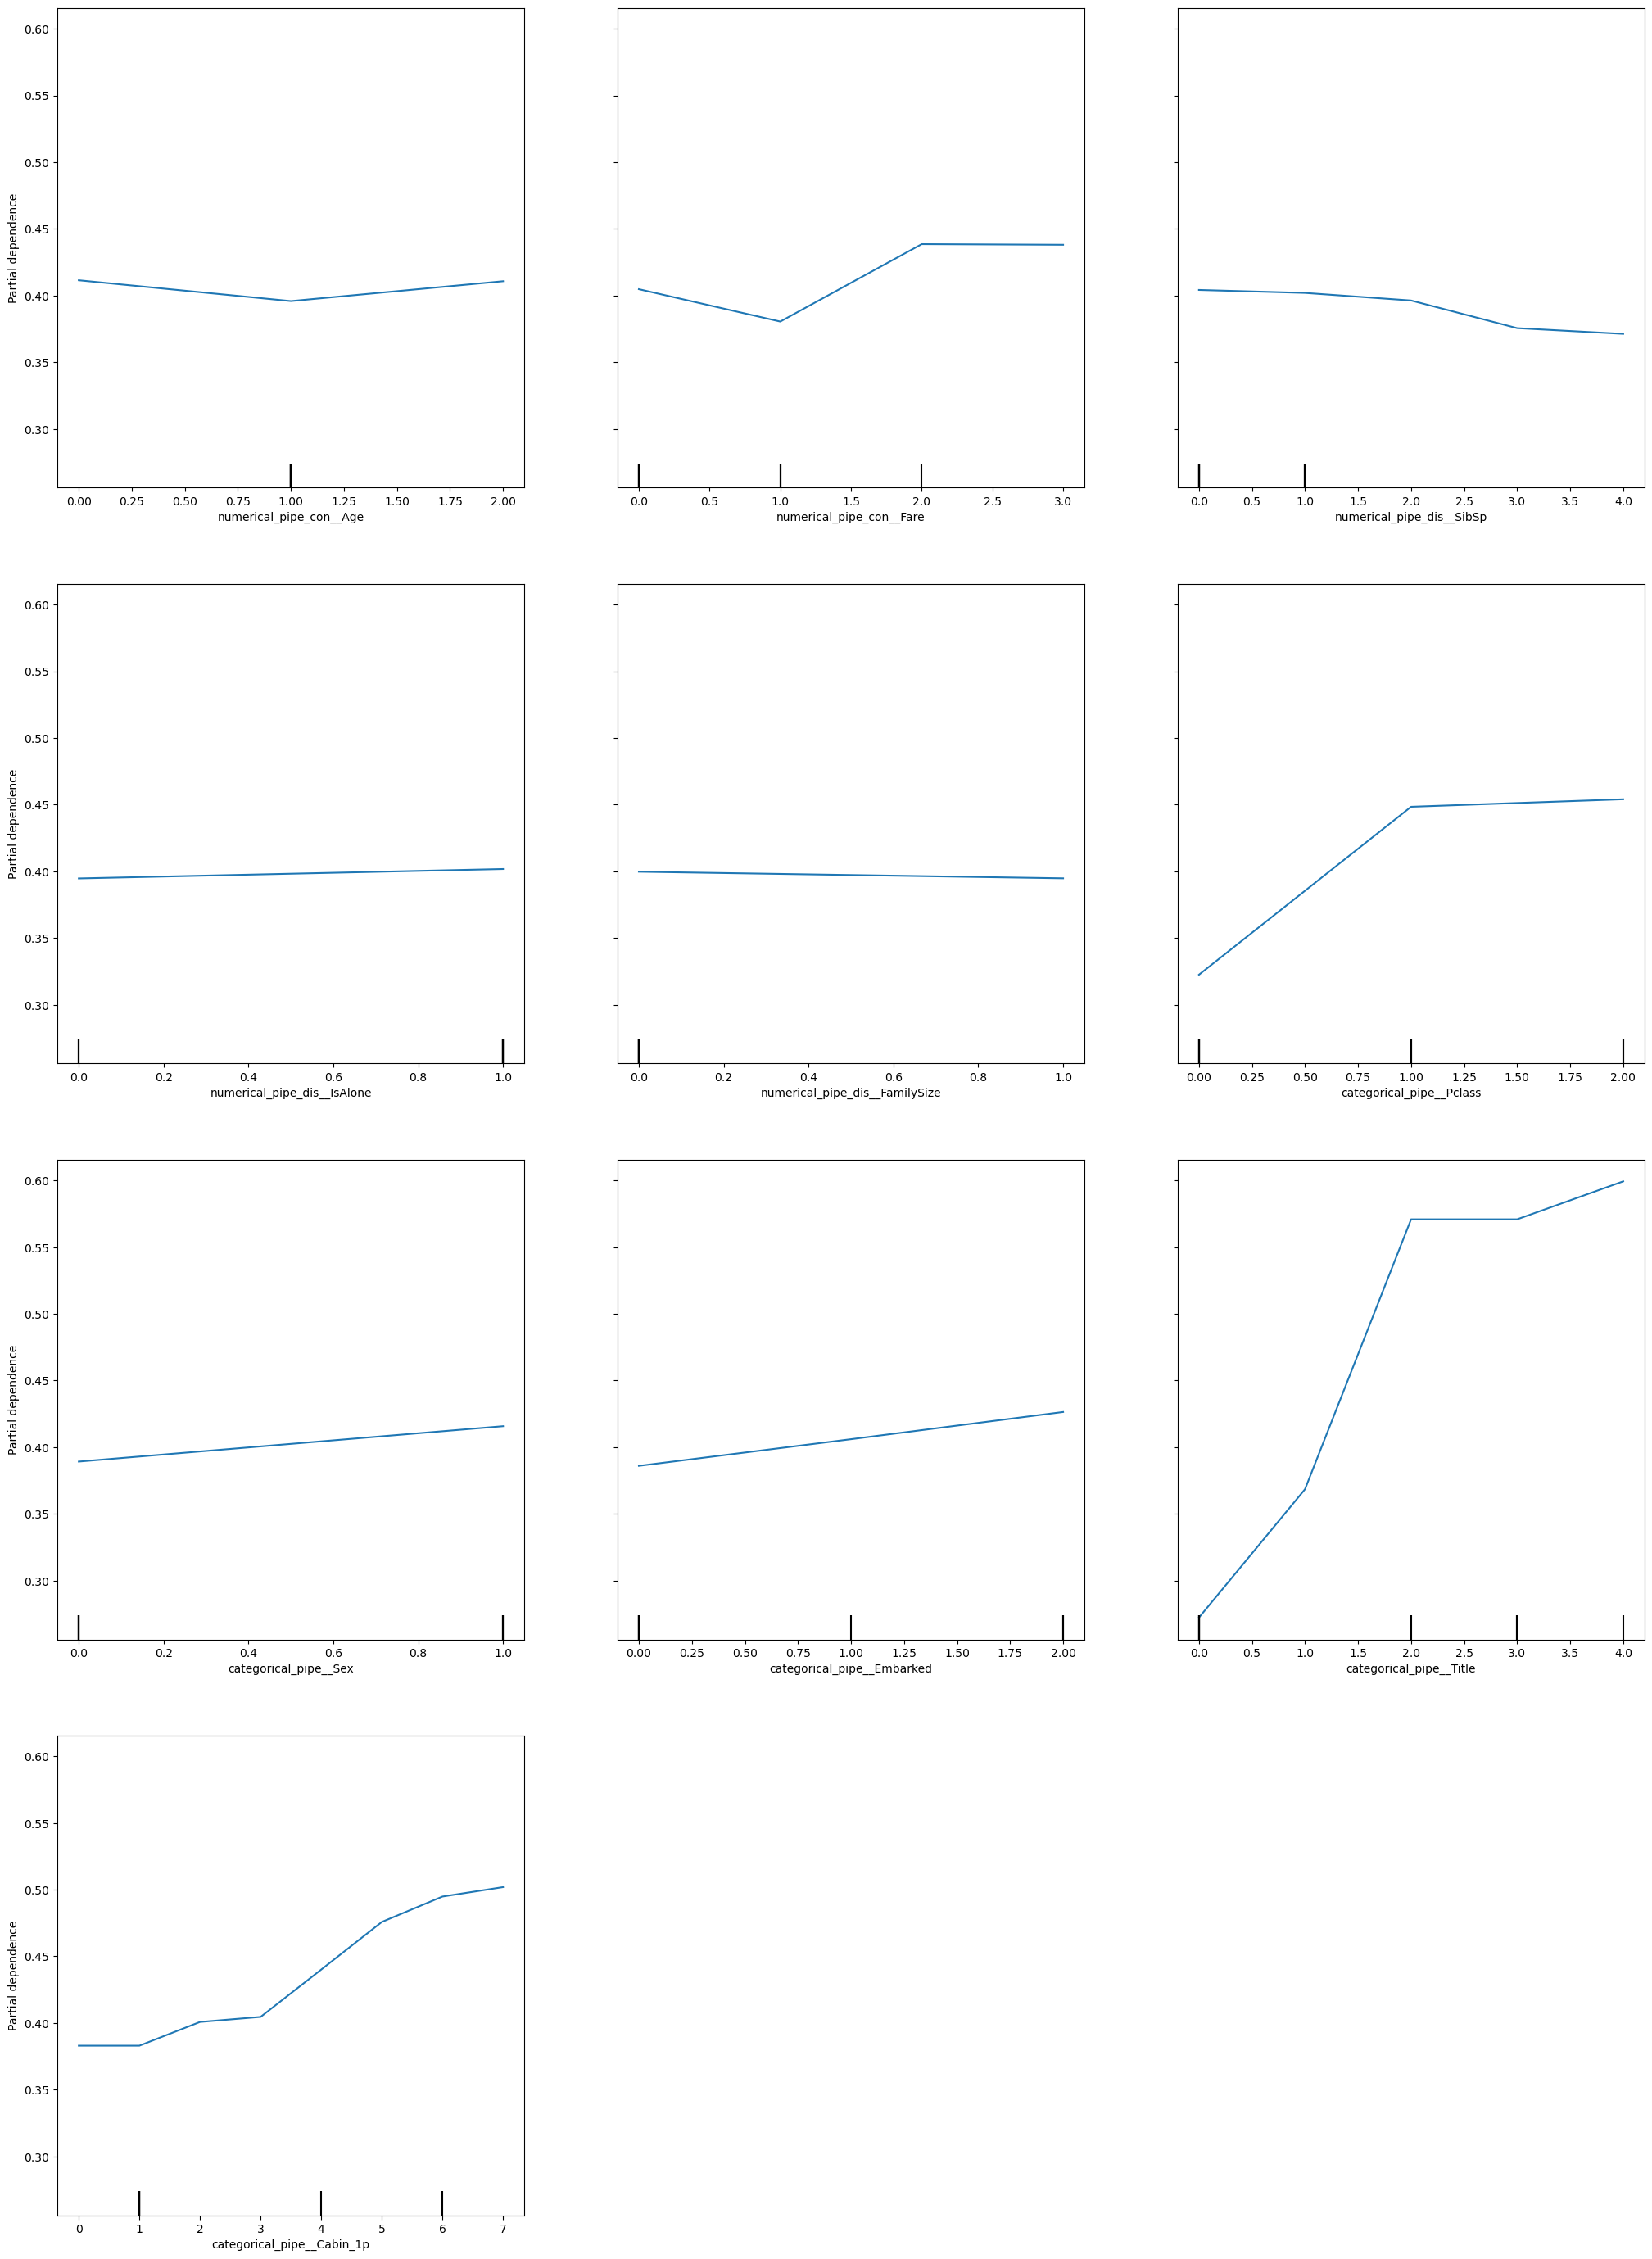

In [12]:
fig, ax = plt.subplots(figsize=(25, 35))
PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_val,
        features = X_val.columns.tolist(),
        # categorical_features=X_val.columns[X_val.columns.str.contains('categorical_pipe')],
        random_state=23,
        ax=ax
    )

# Shap Values

In [13]:
X_val_proba = model.predict_proba(X_val)

In [14]:
explainer = shap.Explainer(model.predict_proba, X_train)

In [15]:
shap_values_train = explainer(X_train)
shap_values_val = explainer(X_val)

ExactExplainer explainer: 713it [00:26, 18.54it/s]                         


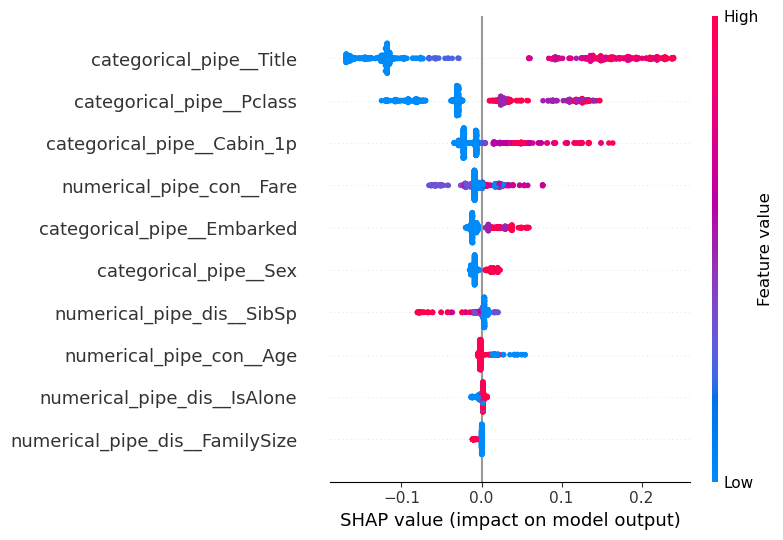

In [16]:
# Classe positiva (geralmente índice 1)
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train
)

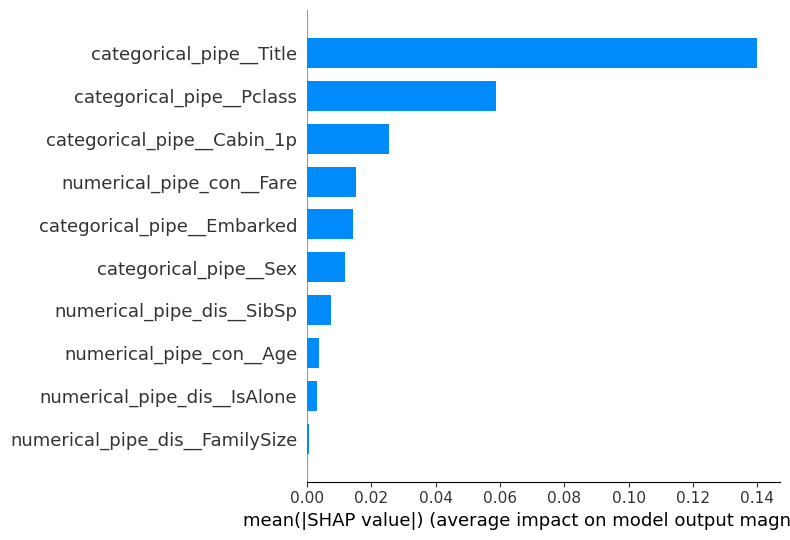

In [17]:
shap.summary_plot(
    shap_values_train.values[:, :, 1],
    X_train,
    plot_type="bar"
)


In [18]:
X_val

,numerical_pipe_con__Age,numerical_pipe_con__Fare,numerical_pipe_dis__SibSp,numerical_pipe_dis__IsAlone,numerical_pipe_dis__FamilySize,categorical_pipe__Pclass,categorical_pipe__Sex,categorical_pipe__Embarked,categorical_pipe__Title,categorical_pipe__Cabin_1p
709,1,0,1.0,0,0,0,0,2,2,1
439,1,0,0.0,1,0,1,0,0,0,1
840,1,0,0.0,1,0,0,0,0,0,1
720,0,1,0.0,0,0,1,1,0,3,1
39,1,0,1.0,0,0,0,1,2,3,1
...,...,...,...,...,...,...,...,...,...,...
433,1,0,0.0,1,0,0,0,0,0,1
773,1,0,0.0,1,0,0,0,2,0,1
25,1,1,1.0,0,1,0,1,0,4,1
84,1,0,0.0,1,0,1,1,0,3,1


In [19]:
X_val.loc[709]

numerical_pipe_con__Age           1.0
numerical_pipe_con__Fare          0.0
numerical_pipe_dis__SibSp         1.0
numerical_pipe_dis__IsAlone       0.0
numerical_pipe_dis__FamilySize    0.0
categorical_pipe__Pclass          0.0
categorical_pipe__Sex             0.0
categorical_pipe__Embarked        2.0
categorical_pipe__Title           2.0
categorical_pipe__Cabin_1p        1.0
Name: 709, dtype: float64

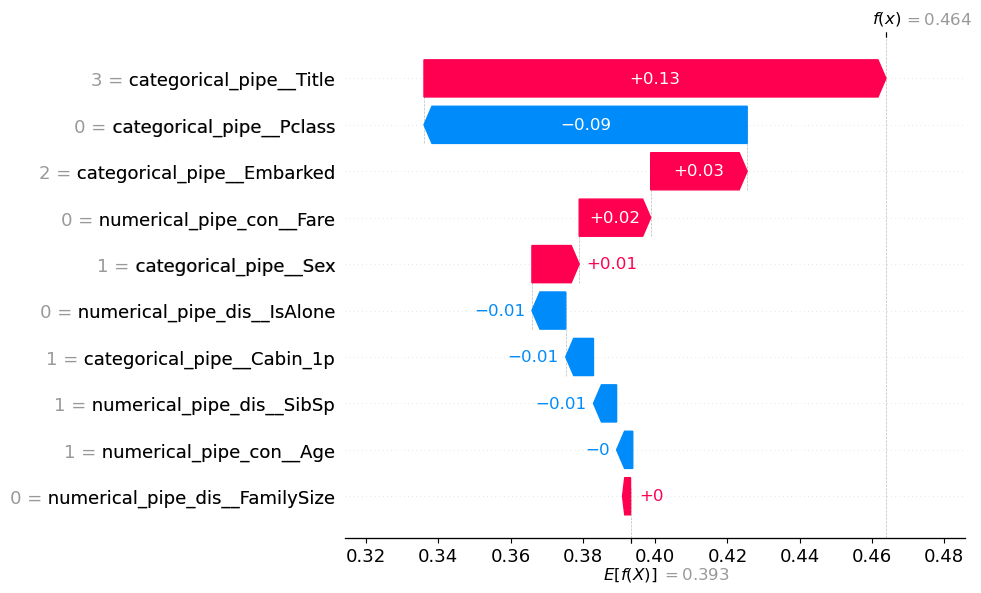

In [20]:
shap.plots.waterfall(shap_values_val[4,:,1])

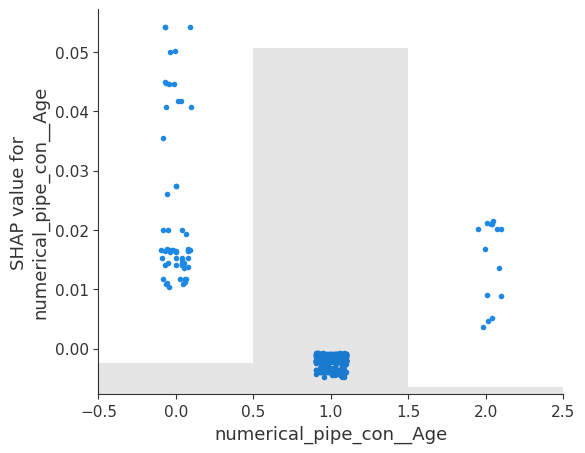

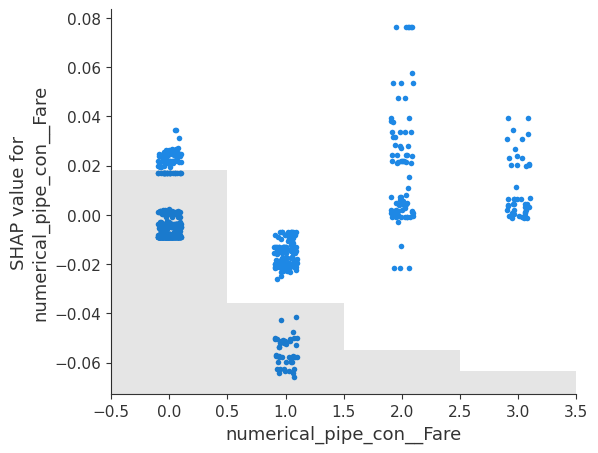

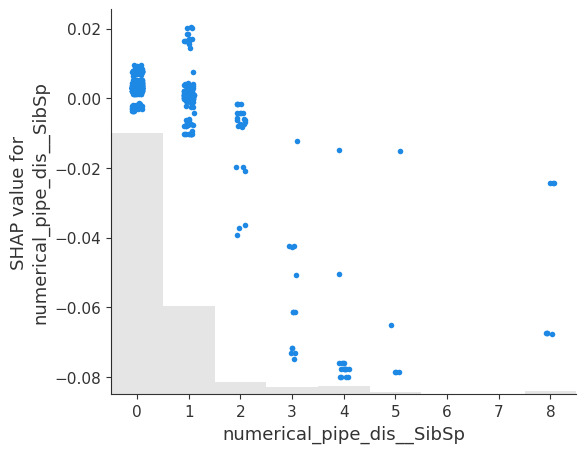

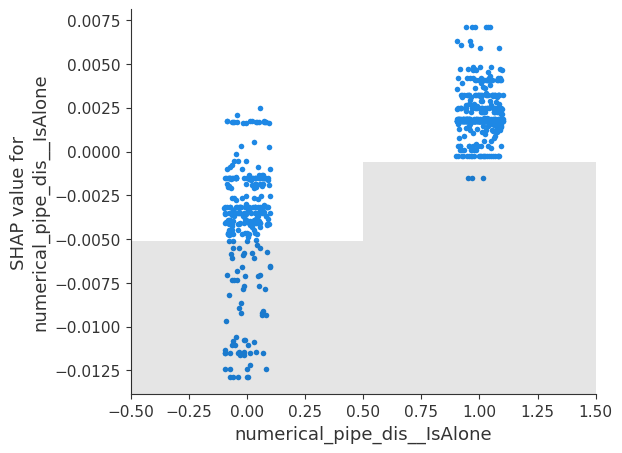

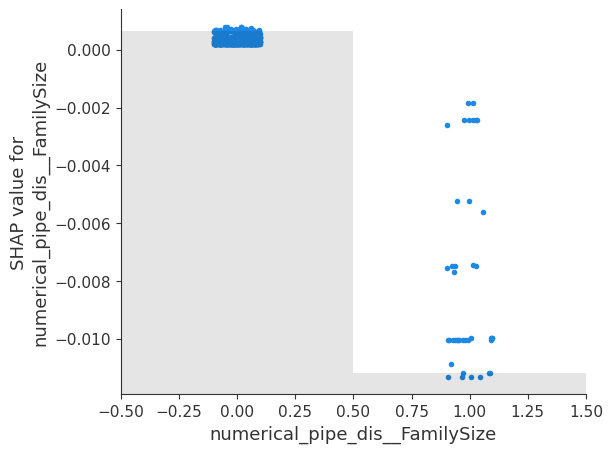

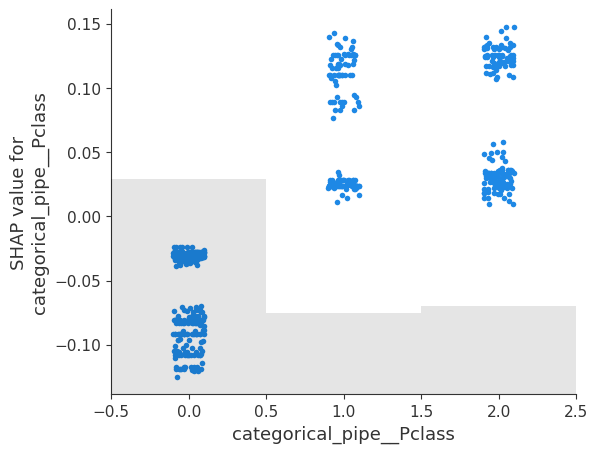

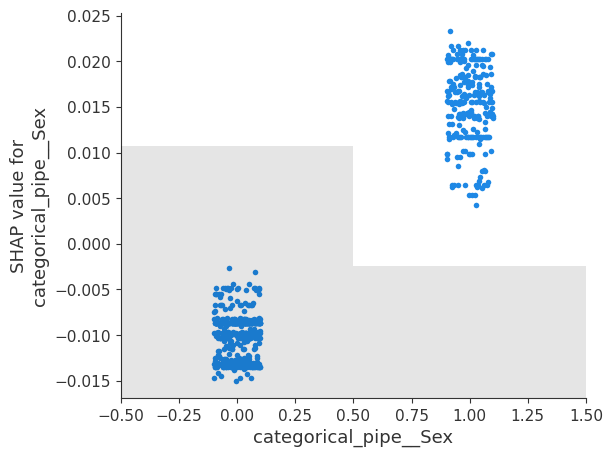

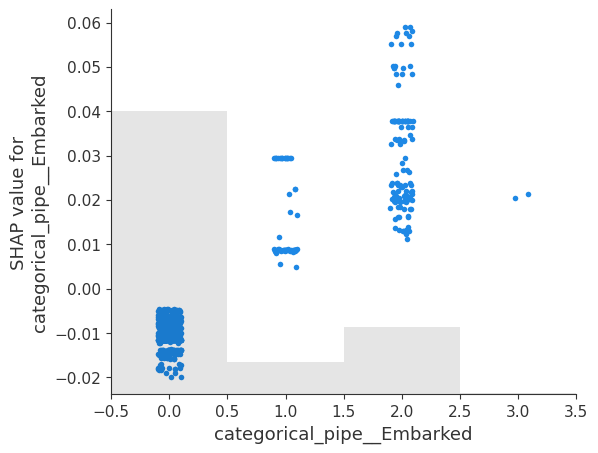

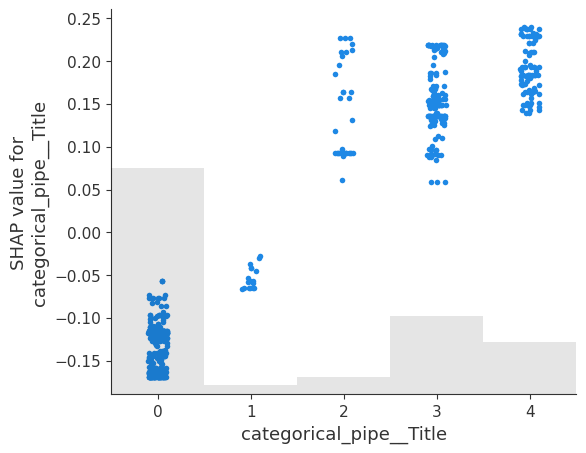

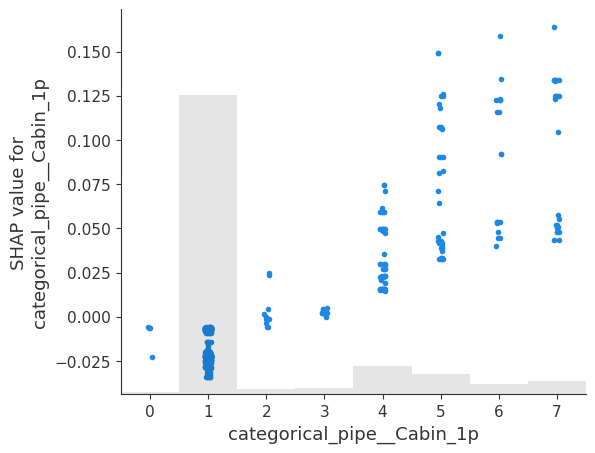

In [21]:
for col in X_val.columns:
    shap.plots.scatter(shap_values_train[:,col,1])

In [22]:
X_train['numerical_pipe_dis__FamilySize'].unique()

array([0, 1], dtype=int64)